## Data Cleaning

In [1]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from pyScripts.utils import *

# 读取 .mat 文件
# mat_data = scipy.io.loadmat('mScripts/simuAndModel/para4_very_high_density/para4_very_high_density_dataset_2000rounds_6UP.mat')
# mat_data = scipy.io.loadmat('mScripts/simuAndModel/para3_high_density/para3_high_density_dataset_2000rounds_6UP.mat')
# mat_data = scipy.io.loadmat('mScripts/simuAndModel/para2_mid_density/para2_mid_density_dataset_2000rounds_6UP.mat')
# mat_data = scipy.io.loadmat('mScripts/simuAndModel/para1_low_density/para1_low_density_dataset_2000rounds_6UP.mat')
# mat_data = scipy.io.loadmat('mScripts/simuAndModel/para_DH_2000/para_DH_2000_dataset_2000rounds_6UP.mat')
mat_data = scipy.io.loadmat('mScripts/simuAndModel/para0_very_low_density/para0_very_low_density_dataset_100rounds_6UP.mat')

# 访问数据
X_temp = mat_data['X']
y_temp = mat_data['y'] # (xSize,ySize,rounds*zSize)
X_temp = np.array(X_temp)
y_temp = np.array(y_temp)
X_coeffs_temp = mat_data['X_coeffs'] # (coeffSize,rounds*zSize)
positions_temp = mat_data['emitters']

In [2]:
# initialize
X = X_temp
y = y_temp
X_coeffs = X_coeffs_temp
positions = positions_temp

In [3]:
# add data
X = np.concatenate((X, X_temp), axis=2)
y = np.concatenate((y, y_temp), axis=2)
X_coeffs = np.concatenate((X_coeffs, X_coeffs_temp), axis=1)

len1, len2 = positions.shape[0], positions_temp.shape[0]
max_len = max(len1, len2)
if len1 < len2:
    positions = np.pad(positions, ((0, max_len - len1), (0, 0), (0, 0)), mode='constant', constant_values=0)
elif len2 < len1:
    positions_temp = np.pad(positions_temp, ((0, max_len - len2), (0, 0), (0, 0)), mode='constant', constant_values=0)

positions = np.concatenate((positions, positions_temp), axis=2)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

X = np.array(X)
y = np.array(y)
X = np.transpose(X, (2, 0, 1))
y = np.transpose(y, (2, 0, 1))
X_coeffs = np.transpose(X_coeffs, (1, 0))
positions = np.transpose(positions,(2, 0, 1))

Now let's test how to turn X, y into data that could be fed into the model.

In [5]:
from sklearn.model_selection import train_test_split
import torch
from torch import nn

X_train, X_test, y_train, y_test, position_train, position_test, coeff_train, coeff_test = train_test_split(X, y, positions, X_coeffs,  test_size=0.1, random_state=42)
# X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape, position_train.shape, position_test.shape

((180, 128, 128),
 (20, 128, 128),
 (180, 128, 128),
 (20, 128, 128),
 (180, 52, 4),
 (20, 52, 4))

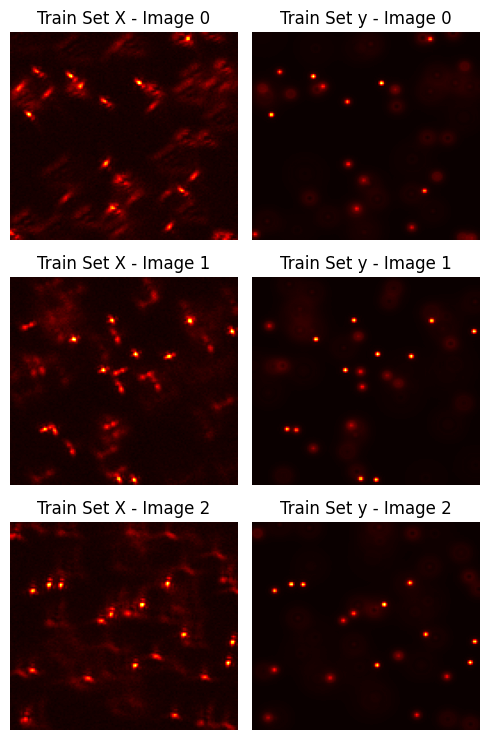

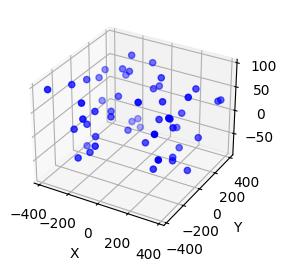

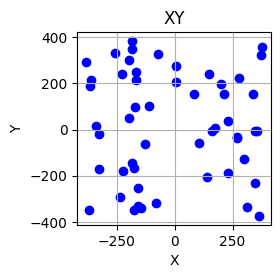

In [6]:
show_two_image(X_train, y_train)
render_3d_position(position_train[0,:])

In [7]:
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [8]:
batch_size = 64
train_iter = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_iter = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test, y_test), batch_size=batch_size)

## Model and Training

Now the structure of the model is built.

In [89]:
from pyScripts.models import EncoderDecoder
net = EncoderDecoder()

Now we turn to the training function

In [90]:
from pyScripts.trainFunctions import *

loss 5.507, train ssim 0.455, test ssim 0.433
112.6 examples/sec on mps


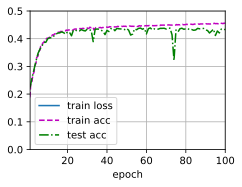

In [92]:
device = torch.device("mps")

lr, num_epochs = 0.001, 100

train_cnn_denoise_deabe(net, train_iter, test_iter, num_epochs, lr, device, L1L2Loss)


In [93]:
torch.save(net, 'net_6000_multi_density.pth')

## Evaluation and Test

In [10]:
net = torch.load('net_6000_multi_density.pth') # load a trained net
net = net.to('cpu') # get it on cpu
y_hat_train = net(X_train)
y_hat_test = net(X_test)

In [11]:
y_hat_train = y_hat_train.detach() # detach from the Graph
y_hat_test = net(X_test).detach()

In [12]:
import tifffile
import pandas as pd
tifffile.imwrite('acc_test/y_hat_train_LOW.tif', y_hat_train.numpy(), dtype='float32')
tifffile.imwrite('acc_test/y_train_LOW.tif', y_train.numpy(), dtype='float32')
tifffile.imwrite('acc_test/X_train_LOW.tif', X_train.numpy(), dtype='float32')
data = []
for img_idx in range(position_train.shape[0]):  # 遍历 18 张图片
    for kp_idx in range(position_train.shape[1]):  # 遍历 52 个关键点
        row = [img_idx, kp_idx] + position_train[img_idx, kp_idx].tolist()  # [图像索引, 关键点索引, x, y, z, w]
        data.append(row)
df = pd.DataFrame(data, columns=['Image_Index', 'Points_Index', 'X', 'Y', 'Z', 'B'])
df.to_csv('acc_test/keypoints_LOW.csv', index=False)

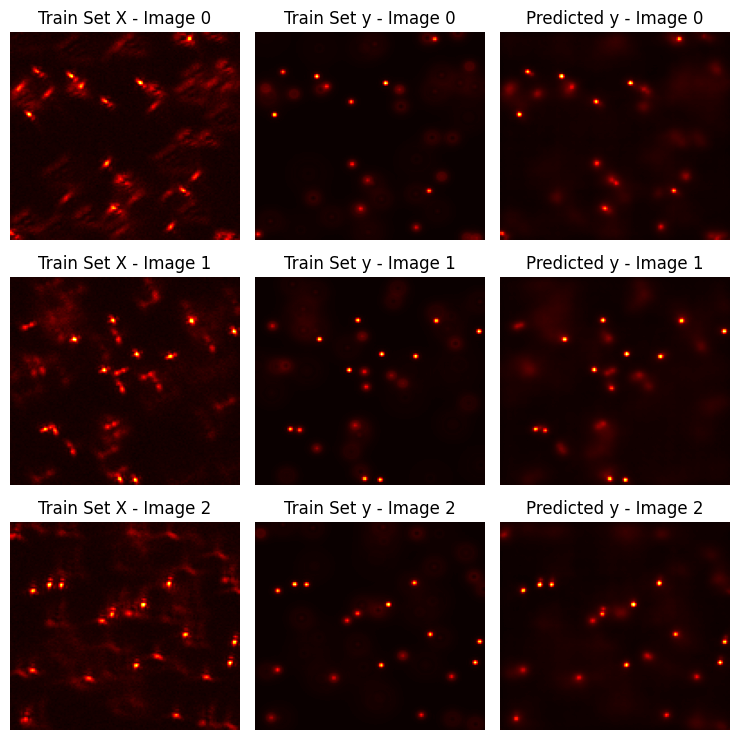

In [13]:
show_three_image(X_train, y_train, y_hat_train)

In [ ]:
print(ssim(y_test, y_hat_test, data_range=1.0))
l1l2loss = L1L2Loss()
l1l2loss(y_hat_train[2], y_train[2])
